# Text Generation using Vanilla RNN, LSTM, and GRU
### Deep Learning | Sequence Modelling Assignment
> **Corpus:** Custom AI/ML paragraph &nbsp;|&nbsp; **Architectures:** SimpleRNN · LSTM · GRU &nbsp;|&nbsp; **Epochs:** 100 (+ 200 student variant)


## Step 1 — Ingest & Clean the Text Corpus


In [1]:
import os, warnings
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
warnings.filterwarnings("ignore")

import numpy as np
import matplotlib.pyplot as plt


corpus_text = """
Artificial intelligence is transforming every aspect of modern life. Machine learning
algorithms can now recognize speech, understand natural language, and generate creative
content. Deep learning models, inspired by the human brain, use layers of artificial
neurons to find patterns in data. Neural networks have achieved superhuman performance
in image recognition, game playing, and protein structure prediction. The field of
natural language processing enables computers to read, understand, and respond to
human language. Recurrent neural networks are specially designed to handle sequential
data such as text and time series. Long short-term memory networks solve the vanishing
gradient problem by using gating mechanisms to control information flow. Gated recurrent
units offer a simpler yet equally powerful alternative to LSTM architectures. Text
generation models learn the statistical structure of language and produce coherent
sentences word by word. Training these models requires large corpora of text and
significant computational resources. Researchers continue to push the boundaries of what
machines can learn and create. The future of artificial intelligence holds enormous
promise for science, medicine, education, and creative expression.
"""


corpus_text = corpus_text.lower().strip()

print(f"Total characters : {len(corpus_text)}")
print(f"Unique words     : {len(set(corpus_text.split()))}")
print("\nFirst 200 chars :", corpus_text[:200])


Total characters : 1259
Unique words     : 129

First 200 chars : artificial intelligence is transforming every aspect of modern life. machine learning
algorithms can now recognize speech, understand natural language, and generate creative
content. deep learning mod


## Step 2 — Tokenization → n-Gram Sequences → pad_sequences
Maps words to integers, builds sliding-window n-grams, and pads to a uniform length.

In [2]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical


tokenizer = Tokenizer()
tokenizer.fit_on_texts([corpus_text])
total_words = len(tokenizer.word_index) + 1   # +1 for OOV/padding index

print(f"Vocabulary size : {total_words}")
print("Sample word→index:", dict(list(tokenizer.word_index.items())[:8]))

input_sequences = []
for line in corpus_text.split("."):
    token_list = tokenizer.texts_to_sequences([line])[0]
    for i in range(1, len(token_list)):
        n_gram = token_list[:i + 1]
        input_sequences.append(n_gram)

print(f"\nTotal n-gram sequences : {len(input_sequences)}")


max_seq_len = max(len(s) for s in input_sequences)
sequences   = np.array(pad_sequences(input_sequences,
                                     maxlen=max_seq_len,
                                     padding="pre"))

X      = sequences[:, :-1]
labels = sequences[:, -1]
y      = to_categorical(labels, num_classes=total_words)

print(f"Max sequence length : {max_seq_len}")
print(f"X shape             : {X.shape}")
print(f"y shape             : {y.shape}")


Vocabulary size : 125
Sample word→index: {'and': 1, 'of': 2, 'to': 3, 'the': 4, 'language': 5, 'artificial': 6, 'models': 7, 'by': 8}

Total n-gram sequences : 163
Max sequence length : 18
X shape             : (163, 17)
y shape             : (163, 125)


## Step 3 — Build Three Sequence Models
> **Student Task 2:** Embedding dim 10 → **64** &nbsp;|&nbsp; **Student Task 4:** Hidden units 64 → **128**

In [3]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense
from tensorflow.keras.optimizers import Adam


EMBED_DIM    = 64    # was 10


HIDDEN_UNITS = 128   # was 64

def build_model(arch: str) -> Sequential:
    model = Sequential(name=arch)
    model.add(Embedding(total_words, EMBED_DIM, input_length=max_seq_len - 1))
    if arch == "SimpleRNN":
        model.add(SimpleRNN(HIDDEN_UNITS))
    elif arch == "LSTM":
        model.add(LSTM(HIDDEN_UNITS))
    elif arch == "GRU":
        model.add(GRU(HIDDEN_UNITS))
    model.add(Dense(total_words, activation="softmax"))
    model.compile(
        loss="categorical_crossentropy",
        optimizer=Adam(learning_rate=0.01),
        metrics=["accuracy"]
    )
    return model


print("=== LSTM Architecture ===")
build_model("LSTM").summary()


=== LSTM Architecture ===


Model: "LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

## Step 4 — Train All Three Models (100 Epochs, Identical Optimizer)
All models use `Adam(lr=0.01)` with `categorical_crossentropy` loss.

In [4]:
EPOCHS = 100   # main requirement

histories = {}
models    = {}

for arch in ["SimpleRNN", "LSTM", "GRU"]:
    print(f"\n▶  Training {arch} ...")
    m = build_model(arch)
    h = m.fit(X, y, epochs=EPOCHS, verbose=0, batch_size=32)
    histories[arch] = h
    models[arch]    = m
    print(f"   Loss @ epoch {EPOCHS}: {h.history['loss'][-1]:.4f}  |  "
          f"Accuracy: {h.history['accuracy'][-1]:.4f}")

print("\nAll three models trained successfully!")



▶  Training SimpleRNN ...
   Loss @ epoch 100: 0.0400  |  Accuracy: 0.9939

▶  Training LSTM ...
   Loss @ epoch 100: 0.0122  |  Accuracy: 0.9939

▶  Training GRU ...
   Loss @ epoch 100: 0.0103  |  Accuracy: 0.9939

All three models trained successfully!


## Step 5 — Training Curve Plot
Line graph comparing cross-entropy loss reduction across all 100 epochs.

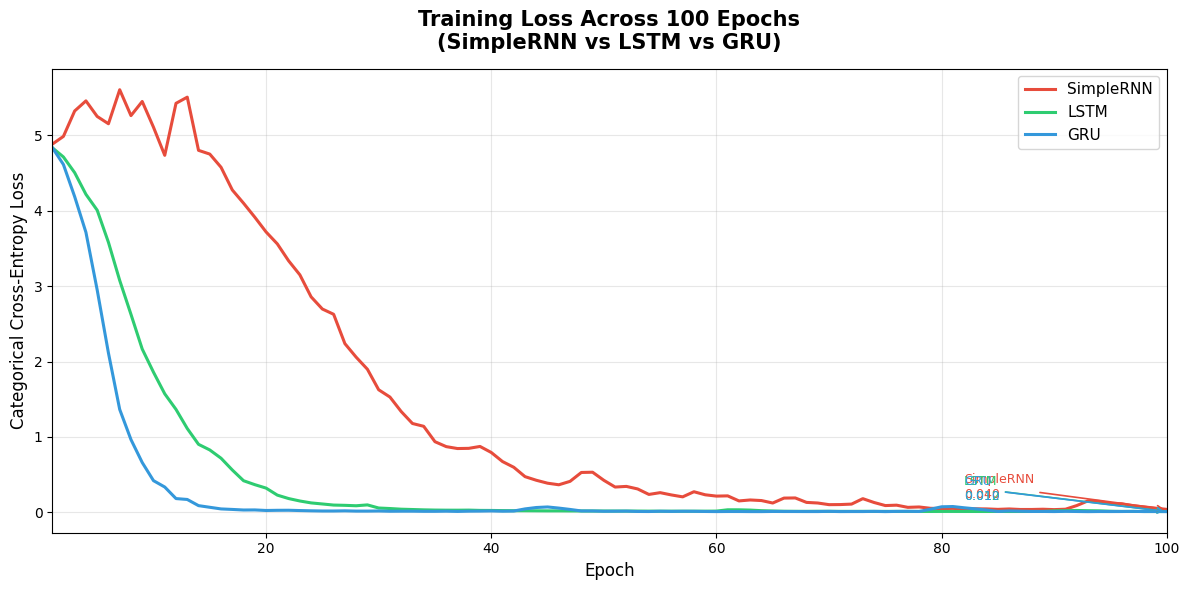

Plot saved as training_curves.png


In [5]:
colors = {"SimpleRNN": "#E74C3C", "LSTM": "#2ECC71", "GRU": "#3498DB"}

fig, ax = plt.subplots(figsize=(12, 6))

for arch, h in histories.items():
    ax.plot(range(1, EPOCHS + 1),
            h.history["loss"],
            color=colors[arch],
            linewidth=2.2,
            label=arch)

ax.set_title("Training Loss Across 100 Epochs\n(SimpleRNN vs LSTM vs GRU)",
             fontsize=15, fontweight="bold", pad=14)
ax.set_xlabel("Epoch", fontsize=12)
ax.set_ylabel("Categorical Cross-Entropy Loss", fontsize=12)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_xlim(1, EPOCHS)

# Annotate final loss values at end of curves
for arch, h in histories.items():
    final = h.history["loss"][-1]
    ax.annotate(f"{arch}\n{final:.3f}",
                xy=(EPOCHS, final),
                xytext=(EPOCHS - 18, final + 0.15),
                fontsize=9, color=colors[arch],
                arrowprops=dict(arrowstyle="->", color=colors[arch], lw=1.2))

plt.tight_layout()
plt.savefig("training_curves.png", dpi=150)
plt.show()
print("Plot saved as training_curves.png")


## Step 6 — `generate_text` with `np.argmax`
The function selects the most probable next word at each step using `np.argmax` over the model's softmax output.

In [6]:

def generate_text(model, seed_text: str, next_words: int = 10) -> str:
    """
    Generates `next_words` words from `seed_text` using the given model.

    Internal logic (STEP 6):
      1. Tokenize and pad the current sequence.
      2. Call model.predict() → get probability array over vocabulary.
      3. Use np.argmax() to pick the index with highest probability.
      4. Reverse-lookup that index in tokenizer.word_index to get the word.
      5. Append word and repeat.
    """
    result = seed_text
    for _ in range(next_words):
        token_list = tokenizer.texts_to_sequences([result])[0]
        token_list = pad_sequences([token_list],
                                   maxlen=max_seq_len - 1,
                                   padding="pre")
        probs = model.predict(token_list, verbose=0)[0]


        predicted_index = np.argmax(probs)

        # Reverse lookup: index → word
        output_word = ""
        for word, idx in tokenizer.word_index.items():
            if idx == predicted_index:
                output_word = word
                break

        result += " " + output_word
    return result


SEED_PHRASE = "artificial intelligence is"

print(f'Seed phrase: "{SEED_PHRASE}"')
print("-" * 65)
for arch, m in models.items():
    generated = generate_text(m, SEED_PHRASE, next_words=10)
    print(f"[{arch:10s}] {generated}")


Seed phrase: "artificial intelligence is"
-----------------------------------------------------------------
[SimpleRNN ] artificial intelligence is transforming every aspect of modern life game playing and protein
[LSTM      ] artificial intelligence is transforming every aspect of modern life life enormous promise for
[GRU       ] artificial intelligence is transforming every aspect of modern life life architectures architectures architectures


Task 1 corpus preview (first 150 chars):
artificial intelligence is transforming every aspect of modern life. machine learning
algorithms can now recognize speech, understand natural language ...

Task 3: Training GRU for 200 epochs ...
  GRU @200 epochs → loss: 0.0098  acc: 0.9939
  Generated: artificial intelligence is transforming every aspect of modern life promise for science medicine



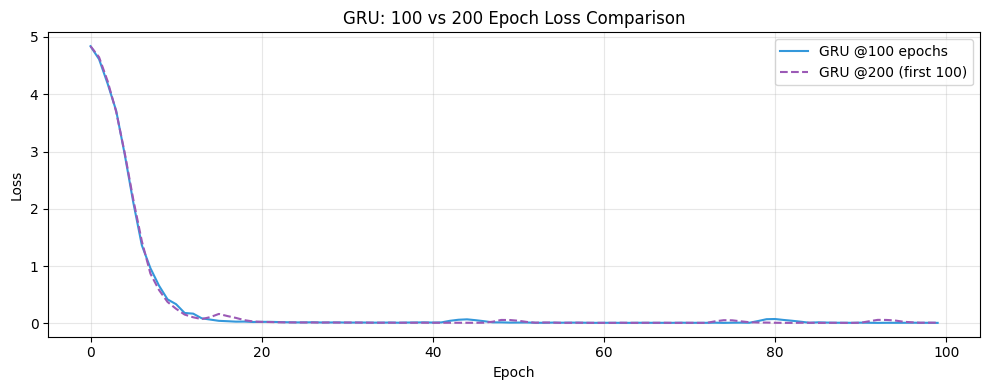

Task 4: HIDDEN_UNITS = 128  (was 64)

Task 5 (10 words): deep learning models inspired by the human brain use layers of artificial neurons


In [8]:

print("Task 1 corpus preview (first 150 chars):")
print(corpus_text[:150], "...\n")

print("Task 3: Training GRU for 200 epochs ...")
gru_200 = build_model("GRU")
h200    = gru_200.fit(X, y, epochs=200, verbose=0, batch_size=32)
print(f"  GRU @200 epochs → loss: {h200.history['loss'][-1]:.4f}  "
      f"acc: {h200.history['accuracy'][-1]:.4f}")
print(f"  Generated: {generate_text(gru_200, SEED_PHRASE, next_words=10)}\n")

# Compare 100 vs 200 epoch loss curves for GRU
plt.figure(figsize=(10, 4))
plt.plot(histories["GRU"].history["loss"], label="GRU @100 epochs", color="#3498DB")
plt.plot(h200.history["loss"][:100],       label="GRU @200 (first 100)", color="#9B59B6", linestyle="--")
plt.title("GRU: 100 vs 200 Epoch Loss Comparison"); plt.xlabel("Epoch")
plt.ylabel("Loss"); plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()


print(f"Task 4: HIDDEN_UNITS = {HIDDEN_UNITS}  (was 64)\n")


sample = generate_text(models["LSTM"], "deep learning models", next_words=10)
print(f"Task 5 (10 words): {sample}")
